# Exploração do CMU Movie Summary Corpus

Estatísticas básicas sobre `data/processed/movies.parquet`, gerado por `src/preprocessing/preprocess.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_parquet("../data/processed/movies.parquet")
df.shape

(42204, 12)

## Número de filmes

In [2]:
print(f"total de filmes: {len(df)}")

total de filmes: 42204


## Gêneros mais comuns

Cada filme pode ter vários gêneros, então contamos ocorrências (não é por filme único).

In [3]:
genre_counts = Counter(g for genres in df["genres"] for g in genres)
top_genres = genre_counts.most_common(15)
pd.DataFrame(top_genres, columns=["genre", "count"])

,genre,count
0,Drama,19134
1,Comedy,10467
2,Romance Film,6666
3,Thriller,6530
4,Action,5868
5,World cinema,5153
6,Crime Fiction,4275
7,Horror,4082
8,Black-and-white,3731
9,Indie,3668


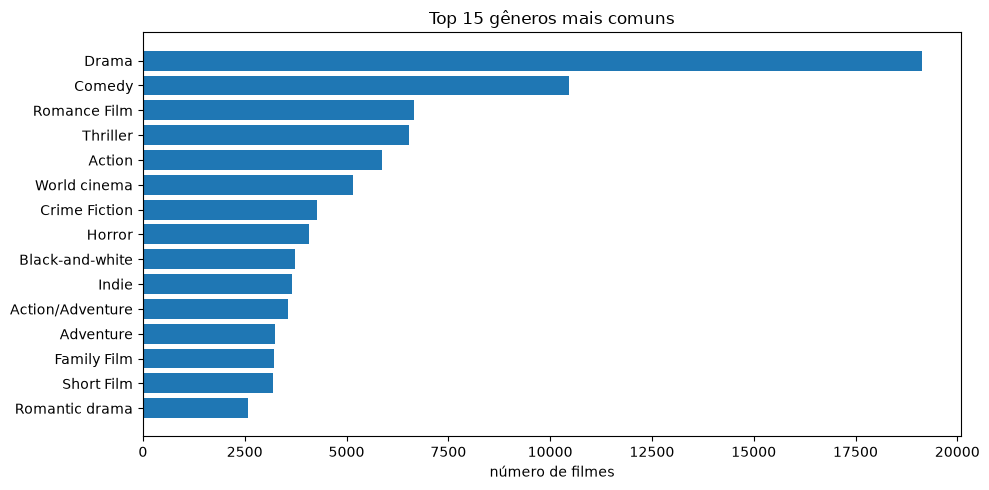

In [4]:
names, counts = zip(*top_genres)
plt.figure(figsize=(10, 5))
plt.barh(names[::-1], counts[::-1])
plt.xlabel("número de filmes")
plt.title("Top 15 gêneros mais comuns")
plt.tight_layout()
plt.show()

## Tamanho das sinopses (em tokens)

In [5]:
token_lengths = df["tokens"].apply(len)
token_lengths.describe()

count    42204.000000
mean       352.164155
std        361.710393
min         10.000000
25%         98.000000
50%        211.000000
75%        514.000000
max       5583.000000
Name: tokens, dtype: float64

In [6]:
print(f"tamanho médio da sinopse: {token_lengths.mean():.1f} tokens")
print(f"mediana: {token_lengths.median():.0f} tokens")

tamanho médio da sinopse: 352.2 tokens
mediana: 211 tokens


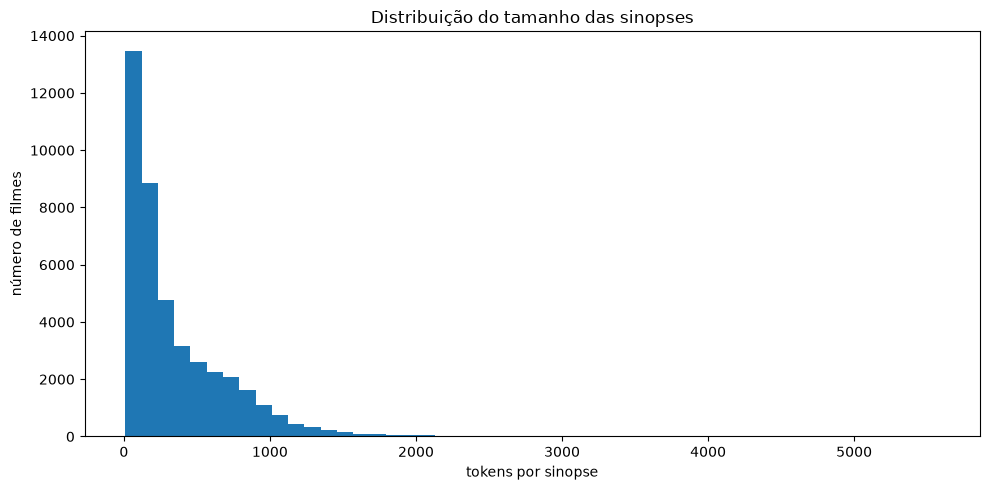

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=50)
plt.xlabel("tokens por sinopse")
plt.ylabel("número de filmes")
plt.title("Distribuição do tamanho das sinopses")
plt.tight_layout()
plt.show()